# Phase 2 — Validation & Ablation Study

This notebook is the follow-up to `05_phase2_models.ipynb`. There are three things it does:

1. Ablation — which pieces of GCMA are actually doing work? We toggle attention, the gate, and the number of learned text views off one at a time and measure the F1 drop relative to the full model.
2. Class-level quality — confusion matrices and a classification report, to see if either class is systematically misclassified.
3. Interpretability — attention heatmap across the test set, gate distribution per outcome class, and a couple of individual Won / Lost examples.

Inputs: `saas_features_pretrained.parquet` (from notebook 04) and `phase2_results.csv` (from 05, for the baseline F1s).

Output: `phase2_ablation_results.csv` plus the plots produced inline.

## Setup

Same imports, seed, and device setup as notebook 05. Seed 42 means the train / val / test split is identical, so the ablation F1s here can be compared directly with the baselines saved by 05.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data loading — same split and rescaling as notebook 05

Re-creates the exact 70/15/15 stratified split (seed 42) and the post-split rescaling. If either step drifts from 05 the numbers below wouldn't be comparable to `phase2_results.csv`.

In [2]:
df = pd.read_parquet("/content/saas_features_pretrained (2).parquet")

TEXT_COLS = [f'tok_{i}' for i in range(768)]
TAB_COLS = [c for c in df.columns if c not in TEXT_COLS and c != 'outcome']
for c in TAB_COLS:
    if df[c].dtype == bool:
        df[c] = df[c].astype(float)

X_tab  = df[TAB_COLS].values.astype(np.float32)
X_text = df[TEXT_COLS].values.astype(np.float32)
y      = df['outcome'].values.astype(np.float32)

X_tab_train, X_tab_temp, X_text_train, X_text_temp, y_train, y_temp = train_test_split(
    X_tab, X_text, y, test_size=0.30, stratify=y, random_state=SEED
)
X_tab_val, X_tab_test, X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_tab_temp, X_text_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

tab_scaler = StandardScaler().fit(X_tab_train)
X_tab_train = tab_scaler.transform(X_tab_train).astype(np.float32)
X_tab_val   = tab_scaler.transform(X_tab_val).astype(np.float32)
X_tab_test  = tab_scaler.transform(X_tab_test).astype(np.float32)

text_scaler = StandardScaler().fit(X_text_train)
X_text_train = text_scaler.transform(X_text_train).astype(np.float32)
X_text_val   = text_scaler.transform(X_text_val).astype(np.float32)
X_text_test  = text_scaler.transform(X_text_test).astype(np.float32)

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

Train: 5600 | Val: 1200 | Test: 1200


## Shared training utilities

Same helpers as notebook 05 — trainer, evaluator, dataloader builder. Keeping the training protocol identical means any F1 difference between ablation variants comes from the architectural change and not from how each variant was trained.

In [3]:
def make_loaders(Xs_train, Xs_val, Xs_test, y_train, y_val, y_test, batch_size=64):
    def to_ds(Xs, y):
        tensors = [torch.tensor(x) for x in Xs] + [torch.tensor(y).float()]
        return TensorDataset(*tensors)
    return (
        DataLoader(to_ds(Xs_train, y_train), batch_size=batch_size, shuffle=True),
        DataLoader(to_ds(Xs_val, y_val), batch_size=batch_size),
        DataLoader(to_ds(Xs_test, y_test), batch_size=batch_size),
    )


def train_model(model, train_loader, val_loader, *, epochs=50, lr=1e-3,
                weight_decay=1e-4, patience=7, label="model"):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    loss_fn = nn.BCEWithLogitsLoss()
    best_val_f1, best_state, bad_epochs = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            *inputs, y_b = [t.to(device) for t in batch]
            opt.zero_grad()
            logits = model(*inputs).squeeze(-1)
            loss = loss_fn(logits, y_b)
            loss.backward()
            opt.step()
        model.eval()
        all_logits, all_y = [], []
        with torch.no_grad():
            for batch in val_loader:
                *inputs, y_b = [t.to(device) for t in batch]
                logits = model(*inputs).squeeze(-1)
                all_logits.append(logits.cpu()); all_y.append(y_b.cpu())
        val_logits = torch.cat(all_logits); val_y = torch.cat(all_y)
        val_preds = (val_logits.sigmoid() >= 0.5).int().numpy()
        val_f1 = f1_score(val_y.numpy(), val_preds)
        scheduler.step(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[{label}] ep {ep:3d} | val F1 = {val_f1:.4f} | best = {best_val_f1:.4f}")
        if bad_epochs >= patience:
            print(f"[{label}] early stop at ep {ep}")
            break
    model.load_state_dict(best_state)
    return model, best_val_f1


@torch.no_grad()
def evaluate(model, loader, label="model"):
    model.eval()
    all_logits, all_y = [], []
    for batch in loader:
        *inputs, y_b = [t.to(device) for t in batch]
        logits = model(*inputs).squeeze(-1)
        all_logits.append(logits.cpu()); all_y.append(y_b.cpu())
    logits = torch.cat(all_logits); ys = torch.cat(all_y)
    preds = (logits.sigmoid() >= 0.5).int().numpy()
    f1 = f1_score(ys.numpy(), preds)
    acc = accuracy_score(ys.numpy(), preds)
    print(f"[{label}] Test F1 = {f1:.4f} | Acc = {acc:.4f}")
    return {'f1': f1, 'acc': acc, 'preds': preds, 'logits': logits.numpy(), 'y': ys.numpy()}

## Load baselines from notebook 05

`phase2_results.csv` has the test F1 and accuracy of TabularMLP, TextMLP, ConcatFusion, and the full GCMAFusion from 05. We pull them in here so the final comparison table includes all the models side by side.

If the CSV isn't there, run 05 first.

In [4]:
try:
    baselines_df = pd.read_csv("/content/phase2_results (1).csv", index_col=0)
    print("Baselines from 05:")
    print(baselines_df.to_string())
except FileNotFoundError:
    print("phase2_results.csv not found — run 05 first. The comparison table below will only show ablation variants.")
    baselines_df = pd.DataFrame(columns=['f1', 'acc'])

Baselines from 05:
                            f1       acc
TextMLP (DistilBERT)  0.704824  0.699167
GCMAFusion            0.961538  0.961667
TabularMLP            0.966443  0.966667
ConcatFusion          0.974874  0.975000


## Parameterized GCMA for ablations

A single `GCMA` class with two boolean flags and a `num_views` integer. Each flag swaps in a controlled alternative:

- `use_attention=False` — the K text views are averaged with equal weight instead of being weighted by the tabular query. This removes the query-conditioned selection while keeping the rest of the pipeline the same.
- `use_gate=False` — the output of the block is the attention output directly, with no learned mixing with the tabular projection. This removes the adaptive modality-trust behaviour.
- `num_views` — the number of learned text views; we test both 8 (default) and 4.

All variants share the tabular encoder, the LayerNorm on the fused output, and the classifier head, so the F1 difference between variants is attributable to the toggled component.

In [5]:
class GCMA(nn.Module):
    def __init__(self, d_tab, d_text=768, d_attn=128, num_views=8,
                 use_attention=True, use_gate=True):
        super().__init__()
        self.num_views     = num_views
        self.d_attn        = d_attn
        self.use_attention = use_attention
        self.use_gate      = use_gate

        self.text_views = nn.Linear(d_text, num_views * d_attn)

        if use_attention:
            self.W_q = nn.Linear(d_tab,  d_attn)
            self.W_k = nn.Linear(d_attn, d_attn)
            self.W_v = nn.Linear(d_attn, d_attn)
            self.scale = (d_attn ** 0.5) * 2.0

        if use_gate:
            self.W_g = nn.Linear(d_tab + d_attn, d_attn)
            nn.init.xavier_normal_(self.W_g.weight, gain=0.1)
            nn.init.zeros_(self.W_g.bias)

        self.tab_proj = nn.Linear(d_tab, d_attn)
        self.ln       = nn.LayerNorm(d_attn)

        self.last_attn_weights = None
        self.last_gate         = None

    def forward(self, h_tab, h_text_cls):
        B = h_tab.size(0)
        h_views = self.text_views(h_text_cls).view(B, self.num_views, self.d_attn)

        if self.use_attention:
            Q = self.W_q(h_tab).unsqueeze(1)      # (B, 1, d_attn)
            K = self.W_k(h_views)                 # (B, K, d_attn)
            V = self.W_v(h_views)                 # (B, K, d_attn)
            scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # (B, 1, K)
            attn   = F.softmax(scores, dim=-1)                          # (B, 1, K)
            z_text = torch.matmul(attn, V).squeeze(1)                   # (B, d_attn)
            self.last_attn_weights = attn.detach().squeeze(1)           # (B, K)
        else:
            z_text = h_views.mean(dim=1)                                # (B, d_attn)
            self.last_attn_weights = None

        h_tab_proj = self.tab_proj(h_tab)                               # (B, d_attn)

        if self.use_gate:
            g = torch.sigmoid(self.W_g(torch.cat([h_tab, z_text], dim=-1)))  # (B, d_attn)
            z_fused = g * z_text + (1.0 - g) * h_tab_proj
            self.last_gate = g.detach()
        else:
            z_fused = z_text
            self.last_gate = None

        return self.ln(z_fused)


class GCMAFusion(nn.Module):
    def __init__(self, d_tab, d_text=768, d_hidden=128, num_views=8,
                 p_drop=0.3, use_attention=True, use_gate=True):
        super().__init__()
        self.tab_enc = nn.Sequential(
            nn.Linear(d_tab, d_hidden),    nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(d_hidden, d_hidden), nn.ReLU(), nn.Dropout(p_drop),
        )
        self.gcma = GCMA(d_tab=d_hidden, d_text=d_text, d_attn=d_hidden,
                         num_views=num_views,
                         use_attention=use_attention, use_gate=use_gate)
        self.head = nn.Sequential(
            nn.Linear(d_hidden, 64), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 1),
        )

    def forward(self, x_tab, x_text):
        h_tab = self.tab_enc(x_tab)
        z_fused = self.gcma(h_tab, x_text)
        return self.head(z_fused)

## Ablation loop — train 4 variants

| Variant     | use_attention      | use_gate         | num_views | What it tests |
|---          |---                 |---               |---        |---            |
| Full GCMA   | yes                | yes              | 8         | Reference |
| − Attention | no (mean of views) | yes              | 8         | Does query-conditioned selection help? |
| − Gate      | yes                | no (z_text only) | 8         | Does adaptive modality trust help? |
| K=4         | yes                | yes              | 4         | Are 8 views needed, or do fewer work? |

The trained full model is cached so the interpretability plots below can reuse it without retraining.

In [6]:
gcma_train, gcma_val, gcma_test = make_loaders(
    [X_tab_train, X_text_train], [X_tab_val, X_text_val], [X_tab_test, X_text_test],
    y_train, y_val, y_test,
)

variants = [
    ("Full GCMA",   {"use_attention": True,  "use_gate": True,  "num_views": 8}),
    ("- Attention", {"use_attention": False, "use_gate": True,  "num_views": 8}),
    ("- Gate",      {"use_attention": True,  "use_gate": False, "num_views": 8}),
    ("K=4",         {"use_attention": True,  "use_gate": True,  "num_views": 4}),
]

ablation_results = {}
full_model = None

for name, kwargs in variants:
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = GCMAFusion(d_tab=X_tab_train.shape[1], **kwargs)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n--- {name} ({n_params:,} params) ---")
    model, _ = train_model(model, gcma_train, gcma_val, label=name)
    ablation_results[name] = evaluate(model, gcma_test, label=name)
    if name == "Full GCMA":
        full_model = model


--- Full GCMA (921,217 params) ---
[Full GCMA] ep   1 | val F1 = 0.9644 | best = 0.9644
[Full GCMA] ep   5 | val F1 = 0.9808 | best = 0.9808
[Full GCMA] ep  10 | val F1 = 0.9748 | best = 0.9808
[Full GCMA] early stop at ep 12
[Full GCMA] Test F1 = 0.9688 | Acc = 0.9692

--- - Attention (871,681 params) ---
[- Attention] ep   1 | val F1 = 0.9630 | best = 0.9630
[- Attention] ep   5 | val F1 = 0.9749 | best = 0.9776
[- Attention] ep  10 | val F1 = 0.9773 | best = 0.9782
[- Attention] early stop at ep 13
[- Attention] Test F1 = 0.9748 | Acc = 0.9750

--- - Gate (888,321 params) ---
[- Gate] ep   1 | val F1 = 0.9535 | best = 0.9535
[- Gate] ep   5 | val F1 = 0.9733 | best = 0.9733
[- Gate] ep  10 | val F1 = 0.9709 | best = 0.9733
[- Gate] early stop at ep 12
[- Gate] Test F1 = 0.9690 | Acc = 0.9692

--- K=4 (527,489 params) ---
[K=4] ep   1 | val F1 = 0.9714 | best = 0.9714
[K=4] ep   5 | val F1 = 0.9708 | best = 0.9739
[K=4] ep  10 | val F1 = 0.9740 | best = 0.9814
[K=4] early stop at ep

## Advanced regularization & self-supervision ablations

Three additional ablations on top of Full GCMA, each isolating a different
data-efficiency lever called out in the Phase 2 rubric for levels 8–10:

- **+ MixUp** — Vicinal Risk Minimization (Zhang et al., 2018) applied to the
  tabular branch. Per batch we sample `λ ~ Beta(α, α)` and train on linear
  interpolations `λ·x_tab_i + (1-λ)·x_tab_j` with soft labels
  `λ·y_i + (1-λ)·y_j`. Text features are held fixed so the cross-modal signal
  is preserved. α = 0.2.

- **+ Curriculum** — Curriculum Learning (Bengio et al., 2009) by
  `conversation_length`. For the first 3 epochs training batches are drawn in
  ascending length order (shortest conversations first); from epoch 4 onwards
  the standard random sampler resumes. Zero architecture change — purely a
  sampler swap.

- **+ SSL pretrain** — Masked Tabular Feature Modeling (Yoon et al., 2020;
  Somepalli et al., 2021). Before supervised training we pretrain the tabular
  encoder to reconstruct 15% randomly-masked features, using train + val
  tabular rows (no labels). The pretrained weights initialize
  `GCMAFusion.tab_enc`; supervised fine-tuning then proceeds as normal.

Each variant is appended to `ablation_results` so the combined table below
picks it up automatically.


In [7]:
# --- + MixUp (alpha = 0.2) on the tabular branch --------------------------------
from torch.utils.data import Sampler


def train_model_mixup(model, train_loader, val_loader, *, alpha=0.2, epochs=50,
                      lr=1e-3, weight_decay=1e-4, patience=7, label="+ MixUp"):
    """Same protocol as `train_model` but applies MixUp on the tabular input
    (the first tensor of each batch) with soft labels. Text features and labels
    are permuted with the same index so the triple stays aligned."""
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    loss_fn = nn.BCEWithLogitsLoss()
    best_val_f1, best_state, bad_epochs = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            x_tab, x_text, y_b = [t.to(device) for t in batch]
            lam = float(np.random.beta(alpha, alpha))
            idx = torch.randperm(x_tab.size(0), device=device)
            x_tab_mix = lam * x_tab + (1.0 - lam) * x_tab[idx]
            y_mix     = lam * y_b   + (1.0 - lam) * y_b[idx]
            opt.zero_grad()
            logits = model(x_tab_mix, x_text).squeeze(-1)
            loss = loss_fn(logits, y_mix)
            loss.backward()
            opt.step()
        model.eval()
        all_logits, all_y = [], []
        with torch.no_grad():
            for batch in val_loader:
                *inputs, y_b = [t.to(device) for t in batch]
                logits = model(*inputs).squeeze(-1)
                all_logits.append(logits.cpu()); all_y.append(y_b.cpu())
        val_f1 = f1_score(torch.cat(all_y).numpy(),
                          (torch.cat(all_logits).sigmoid() >= 0.5).int().numpy())
        scheduler.step(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1, bad_epochs = val_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[{label}] ep {ep:3d} | val F1 = {val_f1:.4f} | best = {best_val_f1:.4f}")
        if bad_epochs >= patience:
            print(f"[{label}] early stop at ep {ep}")
            break
    model.load_state_dict(best_state)
    return model, best_val_f1


torch.manual_seed(SEED); np.random.seed(SEED)
model_mixup = GCMAFusion(d_tab=X_tab_train.shape[1],
                         use_attention=True, use_gate=True, num_views=8)
print("\n--- + MixUp (alpha=0.2) ---")
model_mixup, _ = train_model_mixup(model_mixup, gcma_train, gcma_val,
                                   alpha=0.2, label="+ MixUp")
ablation_results["+ MixUp"] = evaluate(model_mixup, gcma_test, label="+ MixUp")



--- + MixUp (alpha=0.2) ---
[+ MixUp] ep   1 | val F1 = 0.9661 | best = 0.9661
[+ MixUp] ep   5 | val F1 = 0.9781 | best = 0.9781
[+ MixUp] ep  10 | val F1 = 0.9799 | best = 0.9799
[+ MixUp] ep  15 | val F1 = 0.9791 | best = 0.9799
[+ MixUp] ep  20 | val F1 = 0.9808 | best = 0.9815
[+ MixUp] ep  25 | val F1 = 0.9799 | best = 0.9815
[+ MixUp] early stop at ep 25
[+ MixUp] Test F1 = 0.9738 | Acc = 0.9742


In [8]:
# --- + Curriculum (easy -> hard by conversation_length, W = 3 epochs) ----------
# Rank the train set by conversation_length. For the first `warmup` epochs,
# batches are drawn sequentially in ascending-length order (easy first); from
# epoch `warmup` onwards the sampler returns a random permutation.

class CurriculumSampler(Sampler):
    def __init__(self, sorted_idx, epoch_ref, warmup=3):
        self.sorted_idx = sorted_idx
        self.epoch_ref  = epoch_ref   # mutable [epoch_int]
        self.warmup     = warmup

    def __iter__(self):
        if self.epoch_ref[0] < self.warmup:
            return iter(self.sorted_idx.tolist())
        return iter(np.random.permutation(len(self.sorted_idx)).tolist())

    def __len__(self):
        return len(self.sorted_idx)


def train_model_curriculum(model, train_ds, val_loader, epoch_ref, sorted_idx,
                           *, batch_size=64, warmup=3, epochs=50, lr=1e-3,
                           weight_decay=1e-4, patience=7, label="+ Curriculum"):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    loss_fn = nn.BCEWithLogitsLoss()
    best_val_f1, best_state, bad_epochs = -1.0, None, 0
    for ep in range(1, epochs + 1):
        epoch_ref[0] = ep - 1
        sampler = CurriculumSampler(sorted_idx, epoch_ref, warmup=warmup)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
        model.train()
        for batch in train_loader:
            *inputs, y_b = [t.to(device) for t in batch]
            opt.zero_grad()
            logits = model(*inputs).squeeze(-1)
            loss_fn(logits, y_b).backward()
            opt.step()
        model.eval()
        all_logits, all_y = [], []
        with torch.no_grad():
            for batch in val_loader:
                *inputs, y_b = [t.to(device) for t in batch]
                logits = model(*inputs).squeeze(-1)
                all_logits.append(logits.cpu()); all_y.append(y_b.cpu())
        val_f1 = f1_score(torch.cat(all_y).numpy(),
                          (torch.cat(all_logits).sigmoid() >= 0.5).int().numpy())
        scheduler.step(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1, bad_epochs = val_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
        if ep == 1 or ep % 5 == 0:
            phase = "easy->hard" if epoch_ref[0] < warmup else "shuffled"
            print(f"[{label}] ep {ep:3d} | val F1 = {val_f1:.4f} | best = {best_val_f1:.4f} | {phase}")
        if bad_epochs >= patience:
            print(f"[{label}] early stop at ep {ep}")
            break
    model.load_state_dict(best_state)
    return model, best_val_f1


# conversation_length column index in TAB_COLS (scaled values preserve rank).
cl_col_idx    = TAB_COLS.index('conversation_length')
cl_sorted_idx = np.argsort(X_tab_train[:, cl_col_idx])

train_ds_cur = TensorDataset(
    torch.tensor(X_tab_train), torch.tensor(X_text_train), torch.tensor(y_train).float()
)

torch.manual_seed(SEED); np.random.seed(SEED)
epoch_ref = [0]
model_cur = GCMAFusion(d_tab=X_tab_train.shape[1],
                       use_attention=True, use_gate=True, num_views=8)
print("\n--- + Curriculum (conversation_length easy->hard, W=3) ---")
model_cur, _ = train_model_curriculum(model_cur, train_ds_cur, gcma_val,
                                      epoch_ref, cl_sorted_idx,
                                      warmup=3, label="+ Curriculum")
ablation_results["+ Curriculum"] = evaluate(model_cur, gcma_test, label="+ Curriculum")



--- + Curriculum (conversation_length easy->hard, W=3) ---
[+ Curriculum] ep   1 | val F1 = 0.9709 | best = 0.9709 | easy->hard
[+ Curriculum] ep   5 | val F1 = 0.9726 | best = 0.9791 | shuffled
[+ Curriculum] ep  10 | val F1 = 0.9791 | best = 0.9799 | shuffled
[+ Curriculum] early stop at ep 14
[+ Curriculum] Test F1 = 0.9705 | Acc = 0.9708


In [9]:
# --- + SSL pretrain (Masked Tabular Feature Modeling, 15% mask) ----------------
# Pretext task: sample a Bernoulli(0.15) mask m per feature, train the tabular
# encoder + a throwaway linear head to reconstruct the masked positions by MSE
# on the 6,800 train + val tabular rows (no labels). Then transfer the encoder
# into a fresh GCMAFusion and fine-tune with BCE as usual.

D_TAB = X_tab_train.shape[1]

torch.manual_seed(SEED); np.random.seed(SEED)
tab_enc_pretrain = nn.Sequential(
    nn.Linear(D_TAB, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 128),   nn.ReLU(), nn.Dropout(0.3),
).to(device)
recon_head = nn.Linear(128, D_TAB).to(device)

X_ssl = np.concatenate([X_tab_train, X_tab_val], axis=0).astype(np.float32)
ssl_loader = DataLoader(
    TensorDataset(torch.tensor(X_ssl)), batch_size=64, shuffle=True
)

opt_ssl = torch.optim.AdamW(
    list(tab_enc_pretrain.parameters()) + list(recon_head.parameters()),
    lr=1e-3, weight_decay=1e-4,
)
MASK_RATIO = 0.15
SSL_EPOCHS = 20

for ep in range(1, SSL_EPOCHS + 1):
    tab_enc_pretrain.train(); recon_head.train()
    running, n = 0.0, 0
    for (x,) in ssl_loader:
        x = x.to(device)
        mask     = (torch.rand_like(x) < MASK_RATIO).float()    # 1 = masked
        x_masked = x * (1.0 - mask)                             # zero = feature mean (standardized)
        x_hat    = recon_head(tab_enc_pretrain(x_masked))
        se       = (x_hat - x) ** 2 * mask
        loss     = se.sum() / mask.sum().clamp(min=1)
        opt_ssl.zero_grad(); loss.backward(); opt_ssl.step()
        running += loss.item() * x.size(0); n += x.size(0)
    if ep == 1 or ep % 5 == 0:
        print(f"[SSL pretrain] ep {ep:3d} | masked-recon MSE = {running/n:.4f}")

# Transfer pretrained encoder weights into fresh Full GCMA, then supervised fine-tune.
torch.manual_seed(SEED); np.random.seed(SEED)
model_ssl = GCMAFusion(d_tab=D_TAB,
                       use_attention=True, use_gate=True, num_views=8)
# GCMAFusion.tab_enc has identical structure to tab_enc_pretrain.
model_ssl.tab_enc.load_state_dict(tab_enc_pretrain.state_dict())
print("\n--- + SSL pretrain (fine-tuning from MTFM-pretrained tabular encoder) ---")
model_ssl, _ = train_model(model_ssl, gcma_train, gcma_val, label="+ SSL pretrain")
ablation_results["+ SSL pretrain"] = evaluate(model_ssl, gcma_test, label="+ SSL pretrain")


[SSL pretrain] ep   1 | masked-recon MSE = 0.9866
[SSL pretrain] ep   5 | masked-recon MSE = 0.6296
[SSL pretrain] ep  10 | masked-recon MSE = 0.5276
[SSL pretrain] ep  15 | masked-recon MSE = 0.5090
[SSL pretrain] ep  20 | masked-recon MSE = 0.5046

--- + SSL pretrain (fine-tuning from MTFM-pretrained tabular encoder) ---
[+ SSL pretrain] ep   1 | val F1 = 0.9760 | best = 0.9760
[+ SSL pretrain] ep   5 | val F1 = 0.9799 | best = 0.9799
[+ SSL pretrain] ep  10 | val F1 = 0.9742 | best = 0.9799
[+ SSL pretrain] early stop at ep 12
[+ SSL pretrain] Test F1 = 0.9731 | Acc = 0.9733


## Combined results — baselines + ablations

Merge the notebook-05 baselines with the ablation variants into a single sorted table. The `delta_vs_Full` column is what we're really after — if removing a component drops F1 by a material amount, that component is load-bearing.

In [10]:
rows = []
for name, res in ablation_results.items():
    rows.append({"model": name, "f1": res['f1'], "acc": res['acc'], "group": "Ablation"})

for name, row in baselines_df.iterrows():
    rows.append({"model": name, "f1": row['f1'], "acc": row['acc'], "group": "Baseline"})

all_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
full_f1 = ablation_results["Full GCMA"]['f1']
all_df['delta_vs_Full'] = (all_df['f1'] - full_f1).round(4)

print(all_df.to_string(index=False))
all_df.to_csv("phase2_ablation_results.csv", index=False)
print("\nSaved phase2_ablation_results.csv")

               model       f1      acc    group  delta_vs_Full
        ConcatFusion 0.974874 0.975000 Baseline         0.0061
         - Attention 0.974790 0.975000 Ablation         0.0060
             + MixUp 0.973840 0.974167 Ablation         0.0051
      + SSL pretrain 0.973064 0.973333 Ablation         0.0043
                 K=4 0.972789 0.973333 Ablation         0.0040
        + Curriculum 0.970464 0.970833 Ablation         0.0017
              - Gate 0.968986 0.969167 Ablation         0.0002
           Full GCMA 0.968776 0.969167 Ablation         0.0000
          TabularMLP 0.966443 0.966667 Baseline        -0.0023
          GCMAFusion 0.961538 0.961667 Baseline        -0.0072
TextMLP (DistilBERT) 0.704824 0.699167 Baseline        -0.2640

Saved phase2_ablation_results.csv


## Interpretability — confusion matrices

Where does each model go wrong? Side-by-side confusion matrices for Full GCMA, − Attention, and − Gate.

- Diagonal cells are correct predictions (top-left: true Lost, bottom-right: true Won).
- Off-diagonal cells are errors. Any asymmetry would tell us the variant is biased toward predicting one class.

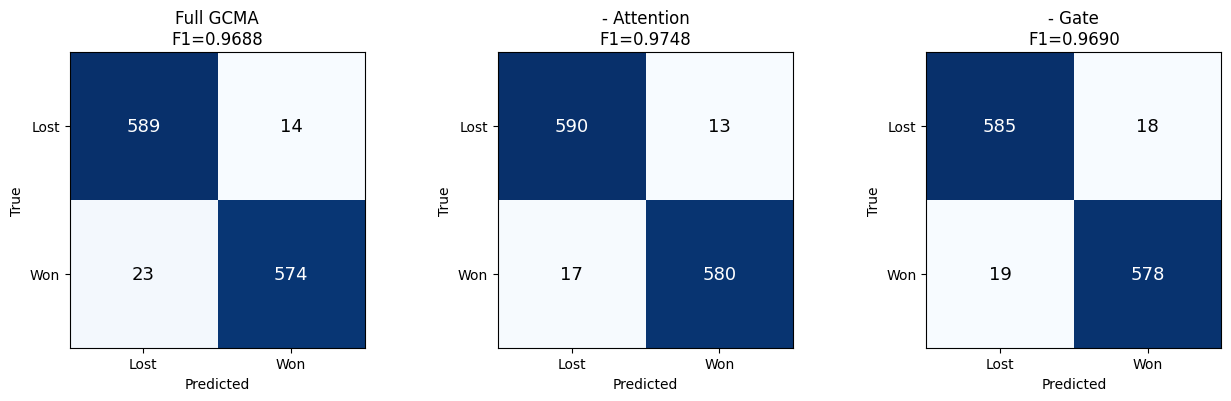

Classification report — Full GCMA:
              precision    recall  f1-score   support

        Lost     0.9624    0.9768    0.9695       603
         Won     0.9762    0.9615    0.9688       597

    accuracy                         0.9692      1200
   macro avg     0.9693    0.9691    0.9692      1200
weighted avg     0.9693    0.9692    0.9692      1200



In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, ["Full GCMA", "- Attention", "- Gate"]):
    res = ablation_results[name]
    cm = confusion_matrix(res['y'], res['preds'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}\nF1={res['f1']:.4f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Lost', 'Won'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Lost', 'Won'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=13)
plt.tight_layout()
plt.show()

print("Classification report — Full GCMA:")
print(classification_report(
    ablation_results["Full GCMA"]['y'],
    ablation_results["Full GCMA"]['preds'],
    target_names=['Lost', 'Won'], digits=4,
))

## Interpretability — cross-modal attention heatmap

The attention weights form an `(N, 8)` matrix where each row is the softmax the tabular query computed over the 8 learned text views for that sample. We sort the samples by outcome to make class-discriminative patterns (if any) visible, and also plot the per-sample entropy:

- Rows with entropy near `log(8) ≈ 2.08` mean attention is uniform — the query doesn't prefer any particular view.
- Low-entropy rows mean the query is consistently concentrating on a small number of views.
- If the entropy distributions for Won vs. Lost look different, the attention is class-discriminative even if the F1 improvement from attention is small.

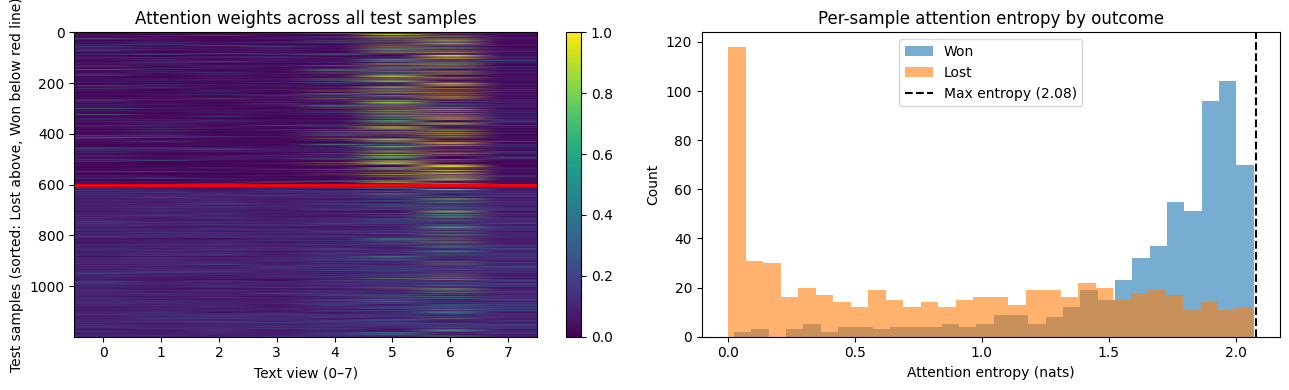

Mean attention entropy: 1.245 nats (max = 2.079)
  Won:  1.684 ± 0.408
  Lost: 0.810 ± 0.660


In [12]:
# Run Full GCMA on test set once to cache attention + gate
full_model.eval()
with torch.no_grad():
    _ = full_model(torch.tensor(X_tab_test).to(device),
                    torch.tensor(X_text_test).to(device))

attn = full_model.gcma.last_attn_weights.cpu().numpy()   # (N_test, 8)
gate = full_model.gcma.last_gate.cpu().numpy()           # (N_test, 128)

# Sort by outcome for visual grouping
order       = np.argsort(y_test)
attn_sorted = attn[order]
y_sorted    = y_test[order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(attn_sorted, aspect='auto', cmap='viridis')
axes[0].axhline(y=(y_sorted == 0).sum(), color='red', linewidth=2)
axes[0].set_xlabel("Text view (0–7)")
axes[0].set_ylabel("Test samples (sorted: Lost above, Won below red line)")
axes[0].set_title("Attention weights across all test samples")
plt.colorbar(im, ax=axes[0])

entropy = -(attn * np.log(attn + 1e-9)).sum(axis=1)
axes[1].hist(entropy[y_test == 1], bins=30, alpha=0.6, label='Won')
axes[1].hist(entropy[y_test == 0], bins=30, alpha=0.6, label='Lost')
axes[1].axvline(np.log(8), color='black', linestyle='--', label=f'Max entropy ({np.log(8):.2f})')
axes[1].set_xlabel("Attention entropy (nats)")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-sample attention entropy by outcome")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean attention entropy: {entropy.mean():.3f} nats (max = {np.log(8):.3f})")
print(f"  Won:  {entropy[y_test == 1].mean():.3f} ± {entropy[y_test == 1].std():.3f}")
print(f"  Lost: {entropy[y_test == 0].mean():.3f} ± {entropy[y_test == 0].std():.3f}")

## Interpretability — gate distribution

The gate is a `(N, 128)` tensor — a per-sample, per-dimension value in `[0, 1]`. We summarise it two ways:

- Left: mean gate across the 128 dimensions, per sample, split by outcome. Class separation means the gate is picking up different modality-trust patterns for Won vs. Lost.
- Right: std of each gate dimension across test samples. If a lot of the 128 dimensions have meaningful per-sample variability, the gate isn't collapsed into a constant.

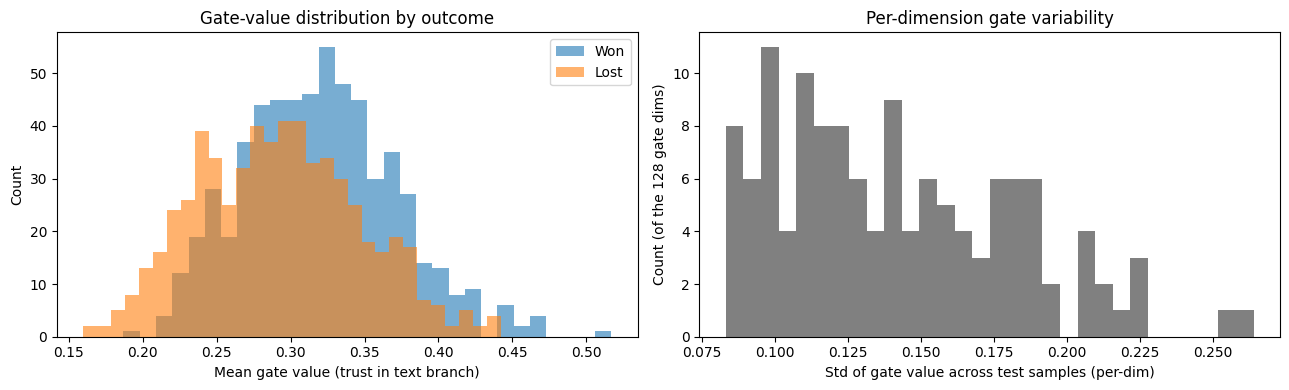

Mean gate (Won):  0.3194 ± 0.0514
Mean gate (Lost): 0.2920 ± 0.0545
Class separation |Δ mean|: 0.0274
Gate per-dim std: mean=0.1418, max=0.2640


In [13]:
gate_trust = gate.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gate_trust[y_test == 1], bins=30, alpha=0.6, label='Won')
axes[0].hist(gate_trust[y_test == 0], bins=30, alpha=0.6, label='Lost')
axes[0].set_xlabel("Mean gate value (trust in text branch)")
axes[0].set_ylabel("Count")
axes[0].set_title("Gate-value distribution by outcome")
axes[0].legend()

gate_per_dim_std = gate.std(axis=0)
axes[1].hist(gate_per_dim_std, bins=30, color='gray')
axes[1].set_xlabel("Std of gate value across test samples (per-dim)")
axes[1].set_ylabel("Count (of the 128 gate dims)")
axes[1].set_title("Per-dimension gate variability")

plt.tight_layout()
plt.show()

mean_won  = gate_trust[y_test == 1].mean()
mean_lost = gate_trust[y_test == 0].mean()
print(f"Mean gate (Won):  {mean_won:.4f} ± {gate_trust[y_test == 1].std():.4f}")
print(f"Mean gate (Lost): {mean_lost:.4f} ± {gate_trust[y_test == 0].std():.4f}")
print(f"Class separation |Δ mean|: {abs(mean_won - mean_lost):.4f}")
print(f"Gate per-dim std: mean={gate_per_dim_std.mean():.4f}, max={gate_per_dim_std.max():.4f}")

## Interpretability — representative Won / Lost examples

One concrete example per class, chosen as the highest-confidence correct prediction in its class. For each we show the attention weights across the 8 learned views and the mean gate value for that sample — i.e. how the model analysed this specific deal.

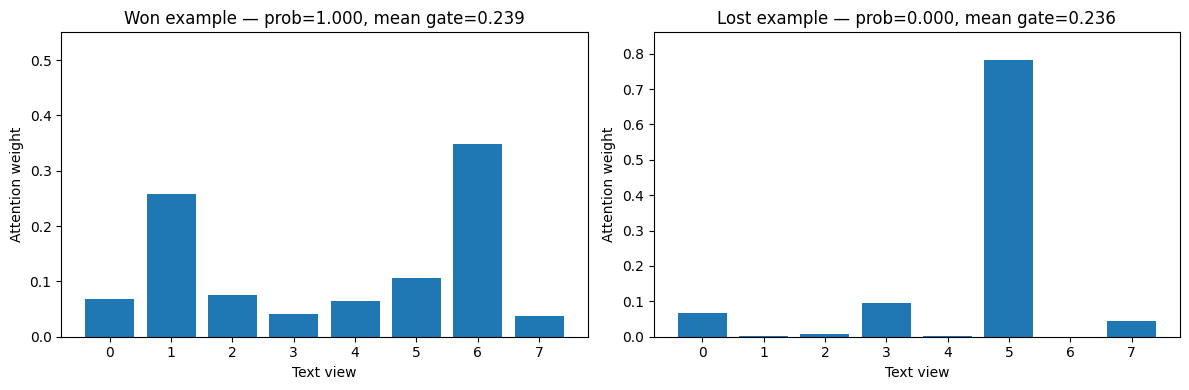


Won example  (idx=696):  top view = 6  (weight 0.349), mean gate = 0.239
Lost example (idx=1069): top view = 5 (weight 0.782), mean gate = 0.236


In [14]:
full_model.eval()
with torch.no_grad():
    logits = full_model(torch.tensor(X_tab_test).to(device),
                         torch.tensor(X_text_test).to(device)).squeeze(-1).cpu().numpy()
probs = 1.0 / (1.0 + np.exp(-logits))

won_idx  = int(np.argmax(probs * (y_test == 1)))           # highest-confidence correct Won
lost_idx = int(np.argmax((1 - probs) * (y_test == 0)))     # highest-confidence correct Lost

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, label in [(axes[0], won_idx, 'Won'), (axes[1], lost_idx, 'Lost')]:
    ax.bar(range(len(attn[idx])), attn[idx])
    ax.set_xlabel("Text view")
    ax.set_ylabel("Attention weight")
    ax.set_title(f"{label} example — prob={probs[idx]:.3f}, mean gate={gate[idx].mean():.3f}")
    ax.set_ylim(0, max(float(attn[idx].max()), 0.5) * 1.1)
plt.tight_layout()
plt.show()

print(f"\nWon example  (idx={won_idx}):  top view = {int(attn[won_idx].argmax())}  (weight {attn[won_idx].max():.3f}), mean gate = {gate[won_idx].mean():.3f}")
print(f"Lost example (idx={lost_idx}): top view = {int(attn[lost_idx].argmax())} (weight {attn[lost_idx].max():.3f}), mean gate = {gate[lost_idx].mean():.3f}")

## Summary

- The ablation table (`phase2_ablation_results.csv`) quantifies each component's contribution by measuring the F1 drop from removing it.
- The confusion matrices and classification report give a per-class view of the errors, useful for spotting precision / recall asymmetries.
- The attention heatmap and entropy histogram check whether the attention is actually being used differently across samples and classes.
- The gate distribution and per-dimension variability check that the gate isn't collapsed to a constant.
- The Won / Lost examples show what a single-sample analysis looks like — which views the attention picked and how much the gate trusted the text for that deal.

If the − Attention or − Gate variants both hurt relative to Full GCMA, the attention + gate design is doing real work; if they don't, we've essentially learned a concat fusion and the architecture could be simplified.